In [18]:
import h5py

fpe = "./data/PE_O5Like_snr20.h5"
f_gw_pix = './data/PE_O5Like_snr20_pixelated_nsidelist512-256-128-64-32-16-8_meanpixels15_skyconf0.9_nestFalse.h5'
file_inj = "./data/injections_Ninj_2e7_O5Like_snr20.h5"

# 中身を表示するためのルール（関数）を定義します
def print_structure(name, obj):
    if isinstance(obj, h5py.Group):
        print(f"\nGroup  : {name}")
    elif isinstance(obj, h5py.Dataset):
        print(f"Dataset: {name} | shape: {obj.shape} | dtype: {obj.dtype}")

with h5py.File(fpe, "r") as f:
    print("=== HDF5ファイルの全階層構造 ===")
    # f（ルート）以下のすべての要素に対して、print_structure関数を適用します
    f.visititems(print_structure)

with h5py.File(f_gw_pix, "r") as f:
    print("\n=== Pixelated HDF5ファイルの全階層構造 ===")
    f.visititems(print_structure)

with h5py.File(file_inj, "r") as f:
    print("\n=== Injection HDF5ファイルの全階層構造 ===")
    f.visititems(print_structure)

=== HDF5ファイルの全階層構造 ===

Group  : posteriors
Dataset: posteriors/dL | shape: (300, 5000) | dtype: float64
Dataset: posteriors/dec | shape: (300, 5000) | dtype: float64
Dataset: posteriors/iota | shape: (300, 5000) | dtype: float64
Dataset: posteriors/m1det | shape: (300, 5000) | dtype: float64
Dataset: posteriors/m2det | shape: (300, 5000) | dtype: float64
Dataset: posteriors/phi | shape: (300, 5000) | dtype: float64
Dataset: posteriors/pix128 | shape: (300, 5000) | dtype: int64
Dataset: posteriors/pix16 | shape: (300, 5000) | dtype: int64
Dataset: posteriors/pix256 | shape: (300, 5000) | dtype: int64
Dataset: posteriors/pix32 | shape: (300, 5000) | dtype: int64
Dataset: posteriors/pix512 | shape: (300, 5000) | dtype: int64
Dataset: posteriors/pix64 | shape: (300, 5000) | dtype: int64
Dataset: posteriors/pix8 | shape: (300, 5000) | dtype: int64
Dataset: posteriors/ra | shape: (300, 5000) | dtype: float64
Dataset: posteriors/theta | shape: (300, 5000) | dtype: float64

Group  : propertie

In [20]:
from CHIMERA import data as data
import h5py
import numpy as np
from CHIMERA import utils

fpe = "./data/PE_O5Like_snr20.h5"

GW_data = {}
with h5py.File(fpe, "r") as f:
    print(f.keys())
    for key in f.keys():
        print(f[key].name)
        # print(f[key].shape)
        # print(f[key].dtype)
        GW_data[key] = f[key]


GW_posteriors = utils.io.load_data_h5(fpe, group_h5='posteriors')
GW_properties = utils.io.load_data_h5(fpe, group_h5='properties')
GW_seeds = utils.io.load_data_h5(fpe, group_h5='seeds')
print(f'posteriors: {GW_posteriors}')
print(f'properties: {GW_properties}')
print(f'seeds: {GW_seeds}')

gw_pe_det = data.load_gw_pe_samples(fpe, parameters=['m1det', 'm2det', 'dL', 'ra', 'dec', 'phi', 'theta'])
gw_pe_det = gw_pe_det.update(pe_prior=gw_pe_det.dL**2)

print(f'gw_pe_det: {gw_pe_det}')
print(np.shape(gw_pe_det.m1det))
print(np.shape(gw_pe_det.pe_prior))

gw_pe_det_pixelated = data.load_pixelated_gw_catalog(f_gw_pix)
print(f'gw_pe_det_pixelated: {gw_pe_det_pixelated}')

<KeysViewHDF5 ['posteriors', 'properties', 'seeds']>
/posteriors
/properties
/seeds
posteriors: {'dL': Array([[7.49719796, 4.03645304, 5.70479481, ..., 6.13666939, 5.52719382,
        5.35879554],
       [2.6319091 , 2.73274883, 2.29574793, ..., 3.12289321, 3.30330348,
        2.63414341],
       [4.84369938, 3.67964237, 2.19489438, ..., 3.31052497, 4.55115897,
        3.63357481],
       ...,
       [1.69557883, 1.7420669 , 2.08390011, ..., 1.78095391, 1.61387442,
        1.4764503 ],
       [3.2348093 , 3.06462645, 2.80219294, ..., 3.21333896, 3.52769835,
        2.72543448],
       [5.49946662, 5.91669065, 5.96210005, ..., 6.33090327, 5.28224601,
        3.67864047]], dtype=float64), 'dec': Array([[0.2053173 , 0.23785795, 0.21592564, ..., 0.19051206, 0.23630537,
        0.16784249],
       [0.37683344, 0.40403361, 0.42998809, ..., 0.40168915, 0.38755714,
        0.37135547],
       [0.39032049, 0.3529966 , 0.3596621 , ..., 0.38183849, 0.34896254,
        0.36210997],
       ...,
   

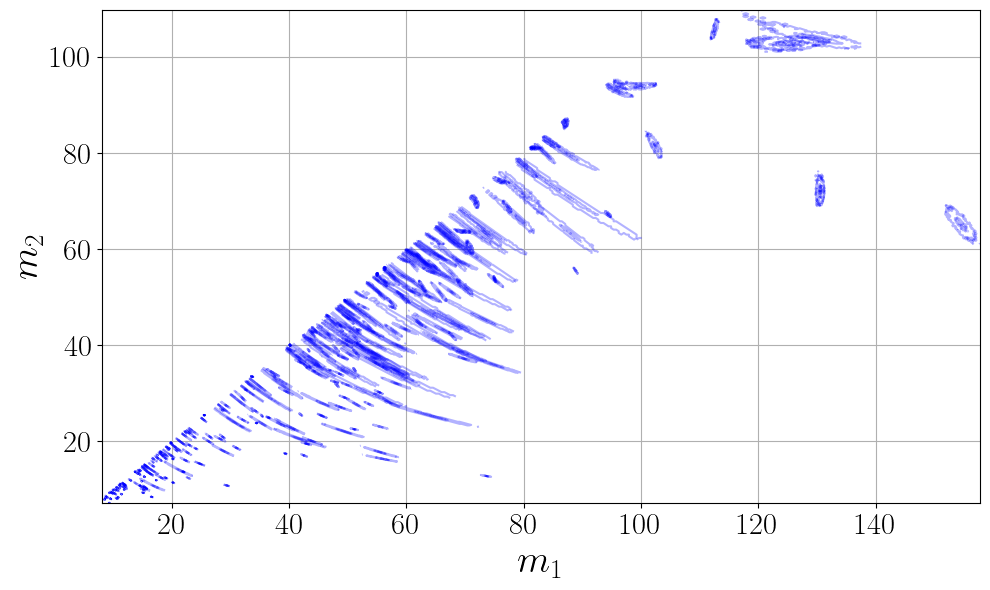

In [54]:
import matplotlib.pyplot as plt

m1det_pos = gw_pe_det.m1det
m2det_pos = gw_pe_det.m2det

plt.style.use('~/research/my_plot_style.style')
plt.figure()

for num in range(len(m1det_pos)):
    counts, xedges, yedges = np.histogram2d(m1det_pos[num], m2det_pos[num], bins=50, density=True)
    xcenters = (xedges[:-1] + xedges[1:]) / 2
    ycenters = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(xcenters, ycenters)    
    plt.contour(X, Y, counts.T, levels=2, alpha=0.3, linewidths=1.5, colors='blue')
plt.xlabel(r'$m_{1}$')
plt.ylabel(r'$m_{2}$')
plt.show()

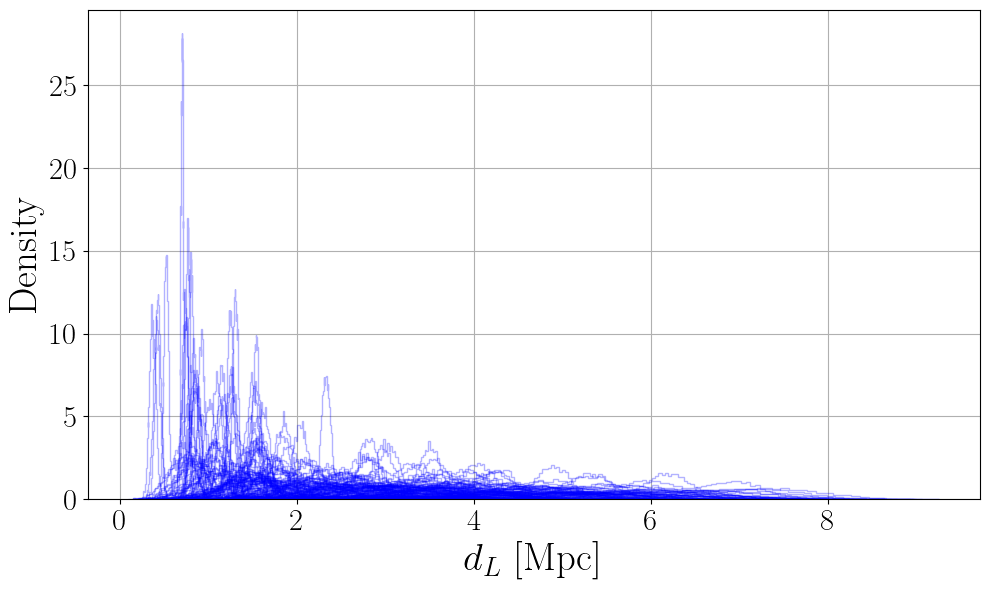

In [ ]:
import matplotlib.pyplot as plt

dL_pos = gw_pe_det.dL

plt.style.use('~/research/my_plot_style.style')
plt.figure()

for num in range(len(dL_pos)):
    plt.hist(dL_pos[num], bins=50, density=True, alpha=0.3, color='blue', histtype='step')
plt.xlabel(r'$d_{L}$~[Gpc]')
plt.ylabel('Density')
plt.show()

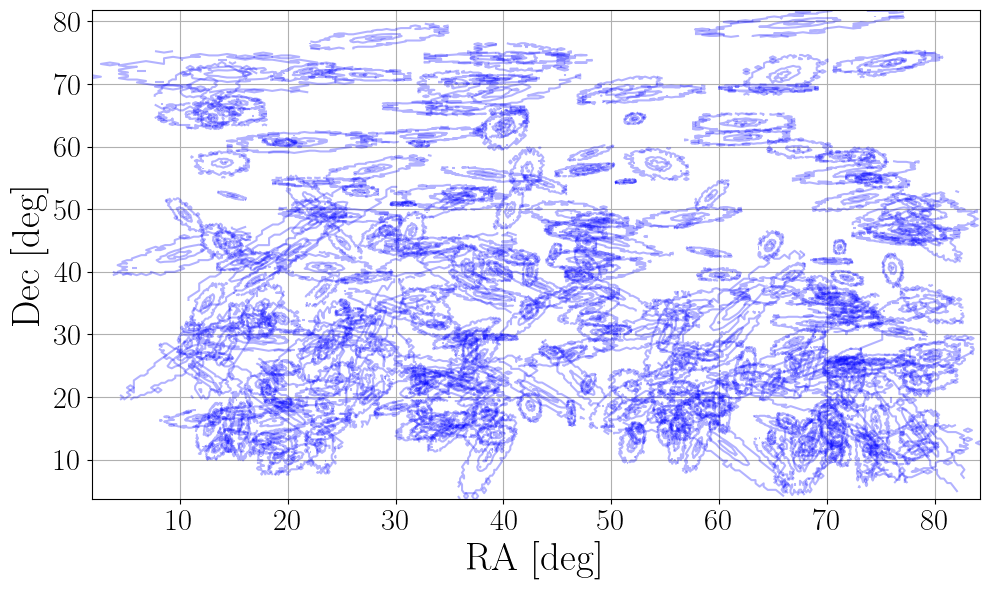

In [51]:
import matplotlib.pyplot as plt

ra_pos = gw_pe_det.ra * 180 / np.pi
dec_pos = gw_pe_det.dec * 180 / np.pi

plt.style.use('~/research/my_plot_style.style')
plt.figure()
for num in range(len(ra_pos)):
    counts, xedges, yedges = np.histogram2d(ra_pos[num], dec_pos[num], bins=30, density=True)
    xcenters = (xedges[:-1] + xedges[1:]) / 2
    ycenters = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(xcenters, ycenters)    
    plt.contour(X, Y, counts.T, levels=2, alpha=0.3, linewidths=1.5, colors='blue')
plt.xlabel(r'RA~[deg]')
plt.ylabel(r'Dec~[deg]')
plt.show()

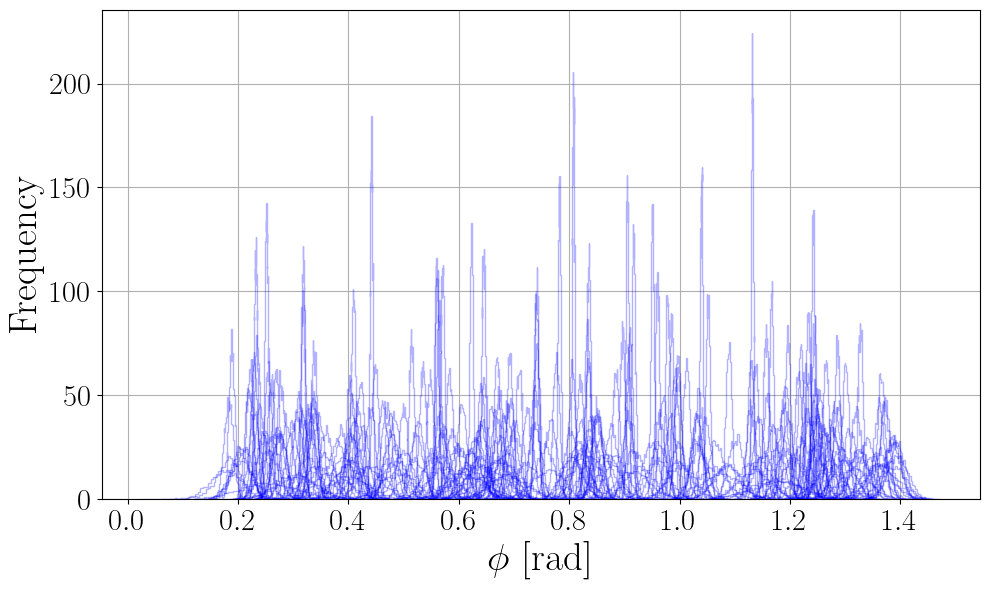

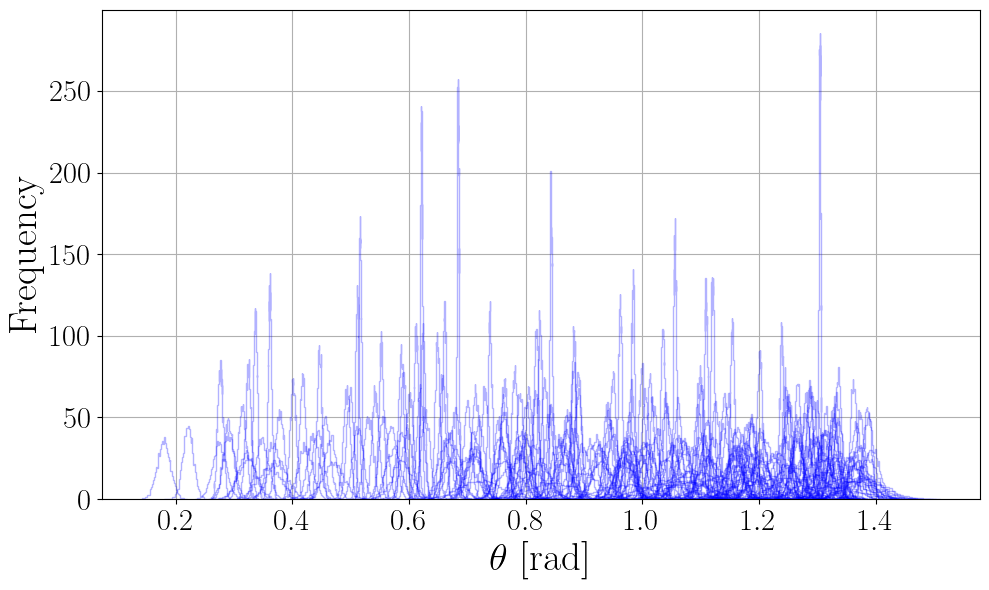

In [47]:
import matplotlib.pyplot as plt

phi_pos = gw_pe_det.phi
theta_pos = gw_pe_det.theta

plt.style.use('~/research/my_plot_style.style')
plt.figure()
for num in range(len(phi_pos)):
    plt.hist(phi_pos[num], bins=50, alpha=0.3, density=True, color='blue', histtype='step')
plt.xlabel(r'$\phi$~[rad]')
plt.ylabel('Frequency')
# plt.legend()
plt.show()

plt.figure()
for num in range(len(theta_pos)):
    plt.hist(theta_pos[num], bins=50, alpha=0.3, density=True, color='blue', histtype='step')
plt.xlabel(r'$\theta$~[rad]')
plt.ylabel('Frequency')
# plt.legend()
plt.show()

sky_area: 1894.0976646995039
Number of events with SNR > 25: 156


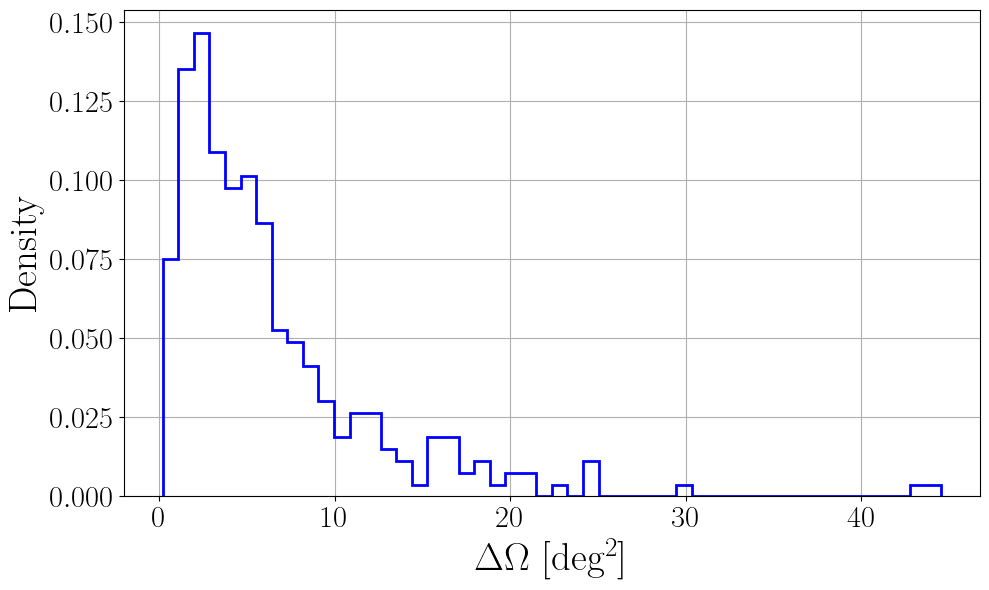

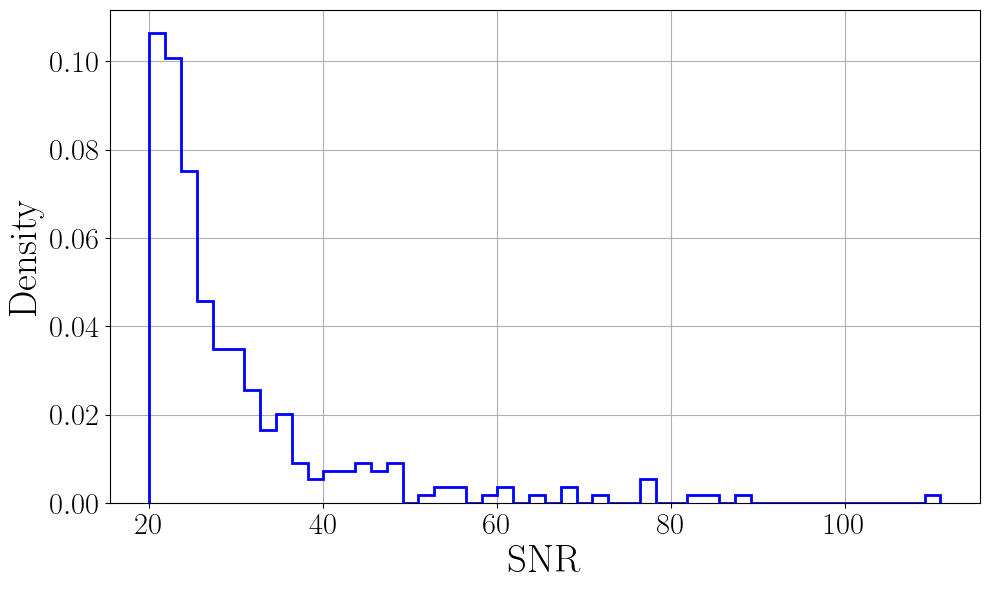

In [17]:
import matplotlib.pyplot as plt

sky_area = GW_properties['sky_area'][:]
snr = GW_properties['snr'][:]

print(f'sky_area: {np.sum(sky_area)}')

mask_snr_25 = snr > 25
print(f'Number of events with SNR > 25: {np.sum(mask_snr_25)}')

plt.style.use('~/research/my_plot_style.style')
plt.figure()
plt.hist(sky_area, bins=50, density=True, color='blue', histtype='step', lw=2)
plt.xlabel(r'$\Delta\Omega$~[deg$^{2}$]')
plt.ylabel('Density')
plt.show()

plt.figure()
plt.hist(snr, bins=50, density=True, color='blue', histtype='step', lw=2)
plt.xlabel('SNR')
plt.ylabel('Density')
plt.show()